In [1]:
import fastparquet as fp
import matplotlib.pyplot as plt
import seaborn as sns

import utils.make_paths_absolute
from utils.plotting_helpers import file_to_qubit_mappings, generate_target_probs_df_from_files, get_files_by_folders

sns.set_style("whitegrid")
sns.set_context("paper")
sns.set_palette("deep", color_codes=True)

In [2]:
file_to_qubit_count_mapping = file_to_qubit_mappings("intermediates/energy_mappings/alt_energies")

warm_start_files = get_files_by_folders(["outputs/npz_files/cold_start_warm_start_comparison/qaoa_results_warmstart1", "outputs/npz_files/cold_start_warm_start_comparison/qaoa_results_warmstart2"])
warm_start_df = generate_target_probs_df_from_files(warm_start_files, file_to_qubit_count_mapping)


cold_start_files = get_files_by_folders(["outputs/npz_files/cold_start_warm_start_comparison/qaoa_results_cold_start"])
cold_start_df = generate_target_probs_df_from_files(cold_start_files, file_to_qubit_count_mapping)

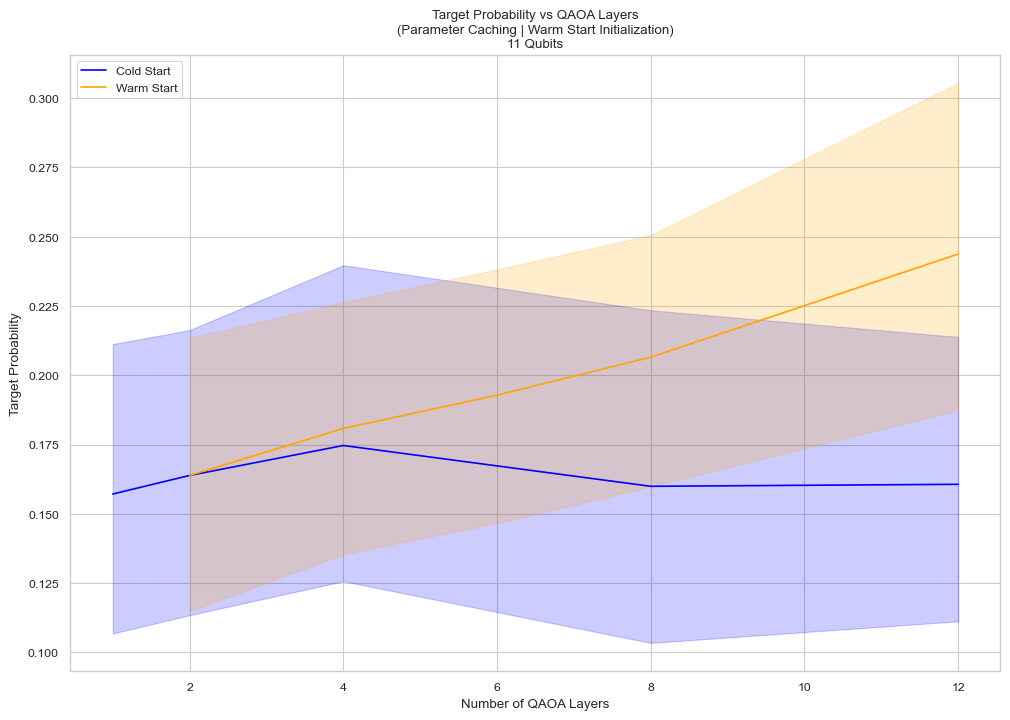

In [3]:
# 11 subsection, = 18-22, length=5, rotmamer_count=4

# Plot cold start vs warm start on the same plot
# One subplot for 11 qubits, one subplot for 12 qubits
cold_start_subset_11 = cold_start_df[cold_start_df['num_qubits'] == 11]

# Filter warm start more aggressively to match the cold start subsections and rotamer counts
warm_start_subset_11 = warm_start_df[warm_start_df['num_qubits'] == 11]
warm_start_subset_11 = warm_start_subset_11[warm_start_subset_11['subsection'] == '18-22']
warm_start_subset_11 = warm_start_subset_11[warm_start_subset_11['rotamer_count'] == 4]

fig, axes = plt.subplots(1, 1, figsize=(12, 8), sharey=True)

sns.lineplot(data=cold_start_subset_11,
             x="qaoa_layers", y="target_prob",
             color='blue',
             markers=True,
             label='Cold Start',
             ax=axes, legend=True)

sns.lineplot(data=warm_start_subset_11,
             x="qaoa_layers", y="target_prob",
            color='orange',
            label='Warm Start',
             ax=axes, legend=True)

axes.set_title("Target Probability vs QAOA Layers\n(Parameter Caching | Warm Start Initialization)\n11 Qubits")
axes.set_xlabel("Number of QAOA Layers")
axes.set_ylabel("Target Probability")

plt.savefig(f"plots/cold_vs_warm_start_probabilities.svg", dpi=300, bbox_inches='tight')
